# BraTS-PEDs 2026 — 3D UNet: **ED Subregion** (Binary: BG vs ED)
**Label map (binary):** `0`=Background · `1`=ED (Peritumoral Edema, original label 4)

**Architecture choices for ED:**
- **T2w + T2f (FLAIR) prioritized** — suppress free CSF, highlight peritumoral swelling
- **Focal Tversky Loss (FTL)+Focal dice loss** — handles severe class imbalance, penalizes FN heavily (β=0.7)
- **CBAM Spatial+Channel Attention** — suppresses background noise, focuses on diffuse edema boundaries
- **Intensity Shifting & Gamma Correction** on T2/FLAIR — robust against fuzzy fluid-tissue contrasts


In [1]:
# ── stdlib ────────────────────────────────────────────────────────────────────
import os, time, random, warnings
from pathlib import Path
from datetime import datetime
from functools import partial
warnings.filterwarnings("ignore")

# ── third-party ───────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from tqdm import tqdm
# ── torch ─────────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.cuda.amp import GradScaler, autocast

torch.backends.cudnn.benchmark = True

# ── MONAI ─────────────────────────────────────────────────────────────────────
from monai.config import print_config
from monai.utils import set_determinism
from monai.utils.enums import MetricReduction
from monai.data import (
    SmartCacheDataset, DataLoader, Dataset,
    decollate_batch, pad_list_data_collate,
)
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Orientationd,
    NormalizeIntensityd, CropForegroundd,
    RandCropByPosNegLabeld, RandFlipd, RandRotate90d,
    RandShiftIntensityd, RandScaleIntensityd, RandGaussianNoised,
    RandAdjustContrastd, RandGaussianSmoothd,
    Activations, AsDiscrete, MapTransform,
)
from monai.networks.nets import UNet
from monai.networks.layers import Norm
from monai.losses import DiceLoss
from monai.metrics import DiceMetric, HausdorffDistanceMetric
from monai.inferers import sliding_window_inference

NUM_GPUS = torch.cuda.device_count()
DEVICE   = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print_config()
print(f"\nPyTorch {torch.__version__} | CUDA: {torch.cuda.is_available()}")
print(f"GPUs found: {NUM_GPUS}")
for i in range(NUM_GPUS):
    vram = round(torch.cuda.get_device_properties(i).total_memory / 1e9, 1)
    print(f"  GPU {i}: {torch.cuda.get_device_name(i)}  ({vram} GB)")


C:\Users\DELL\anaconda3\Lib\site-packages\ignite\handlers\checkpoint.py:17: DeprecationWarning: `TorchScript` support for functional optimizers is deprecated and will be removed in a future PyTorch release. Consider using the `torch.compile` optimizer instead.
  from torch.distributed.optim import ZeroRedundancyOptimizer


MONAI version: 1.5.2
Numpy version: 1.26.4
Pytorch version: 2.5.1+cu121
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: d18565fb3e4fd8c556707f91ac280a2dc3f681c1
MONAI __file__: C:\Users\<username>\anaconda3\Lib\site-packages\monai\__init__.py

Optional dependencies:
Pytorch Ignite version: 0.4.11
ITK version: 5.4.6
Nibabel version: 5.4.2
scikit-image version: 0.24.0
scipy version: 1.13.1
Pillow version: 12.2.0
Tensorboard version: 2.20.0
gdown version: 5.2.0
TorchVision version: 0.20.1+cu121
tqdm version: 4.66.5
lmdb version: 1.4.1
psutil version: 5.9.0
pandas version: 2.3.3
einops version: 0.8.2
transformers version: NOT INSTALLED or UNKNOWN VERSION.
mlflow version: 3.11.1
pynrrd version: 1.1.3
clearml version: 2.1.6rc0

For details about installing the optional dependencies, please visit:
    https://docs.monai.io/en/latest/installation.html#installing-the-recommended-dependencies


PyTorch 2.5.1+cu121 | CUDA: True
GPUs found: 1
  GPU 0: NVIDIA

## Cell 2 — Configuration
**Edit the two paths. Everything else is pre-tuned for ED subregion on 2× A100/H100.**

In [2]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  EDIT THESE PATHS                                           ║
# ╚══════════════════════════════════════════════════════════════╝
DATA_ROOT        = Path(r"C:\Users\DELL\Desktop\BraTS26\All_data_Deskullp\Train")
EXPERIMENTS_ROOT = Path(r"C:\Users\DELL\Desktop\BraTS26\Models\Unet_ED")

MODEL_NAME = "3DUNet_ED_BinarySubregion"
MODEL_ROOT = EXPERIMENTS_ROOT / MODEL_NAME
RUN_NAME   = f"run_{datetime.now():%Y%m%d_%H%M}"
RUN_DIR    = MODEL_ROOT / RUN_NAME
for sub in ["", "figures", "predictions", "checkpoints"]:
    (RUN_DIR / sub).mkdir(parents=True, exist_ok=True)
print("Run directory:", RUN_DIR)

SEED = 42
set_determinism(seed=SEED)
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

SPLIT_RATIOS = (0.80, 0.20)

# ── ED-specific: PRIORITIZE T2w and T2f (FLAIR) ──────────────────────────────
# T2w  = bright in oedema, helps see peritumoral swelling
# T2f  = FLAIR, suppresses free CSF signal, highlights infiltrative edema
# T1n and T1c are still loaded (used for foreground crop) but weighted less
IMAGE_KEYS     = ["t1n", "t1c", "t2w", "t2f"]   # all 4 modalities loaded
ED_KEYS        = ["t2w", "t2f"]                   # T2/FLAIR — primary ED contrast
ALL_KEYS       = IMAGE_KEYS + ["label"]

# ── Binary task: BG=0, ED=1 ───────────────────────────────────────────────────
# in_channels  = 4  (all modalities — architecture unchanged)
# out_channels = 2  (BG=0, ED=1)
# Label remapping: original label 4 (ED) → 1; everything else → 0
IN_CHANNELS  = 4
OUT_CHANNELS = 2   # Binary: BG + ED

PATCH_SIZE          = (96, 96, 96)          #sub volumes
SW_ROI              = (96, 96, 96)          #sliding window region of interest( sub volume window size used during validation)
SW_BATCH            = 4                     #process 2 patches simultaneously
SW_OVERLAP          = 0.25                  #0.25 overlap between adjacent windows
NUM_POS_NEG_SAMPLES = 4                     #extract 4 positive and 4 negative patches

UNET_CHANNELS = (32, 64, 128, 256, 320)       #no.filters at each level
UNET_STRIDES  = (2, 2, 2, 2)               #96/(2*2*2*2)
NUM_RES_UNITS = 2                         #residual units

MAX_EPOCHS          = 200
VAL_INTERVAL        = 2
BATCH_SIZE          = 2 * max(NUM_GPUS, 1)
VAL_BATCH_SIZE      = 1
LEARNING_RATE       = 1e-4
WEIGHT_DECAY        = 1e-5
USE_AMP             = True
CACHE_RATE          = 1
EARLY_STOP_PATIENCE = 40

DL_NUM_WORKERS    = 0
CACHE_NUM_WORKERS = 0
BEST_MODEL_NAME   = "best_3dunet_ed.pth"

# ── Focal Tversky Loss hyperparameters ────────────────────────────────────────
# alpha=0.3, beta=0.7 → penalize False Negatives more (ED can be missed easily)
# gamma=0.75 → focal factor, focuses on hard/uncertain boundary voxels
FTL_ALPHA = 0.3
FTL_BETA  = 0.7
FTL_GAMMA = 0.75

COMBINED_FTL_WEIGHT = 0.65   # Higher = more focus on imbalance/hard examples
COMBINED_CE_WEIGHT  = 0.35   # Lower = more stable gradients

print(f"Input channels  : {IN_CHANNELS}  {IMAGE_KEYS}")
print(f"Output channels : {OUT_CHANNELS}  (BG=0, ED=1)")
print(f"T2/FLAIR keys   : {ED_KEYS}  ← intensity augmentation applied here")
print(f"FTL params      : alpha={FTL_ALPHA}, beta={FTL_BETA}, gamma={FTL_GAMMA}")
print(f"Loss            : Combined (FTL {COMBINED_FTL_WEIGHT:.2f} + DiceCE {COMBINED_CE_WEIGHT:.2f})")
print(f"Device          : {DEVICE}")


Run directory: C:\Users\DELL\Desktop\BraTS26\Models\Unet_ED\3DUNet_ED_BinarySubregion\run_20260622_1354
Input channels  : 4  ['t1n', 't1c', 't2w', 't2f']
Output channels : 2  (BG=0, ED=1)
T2/FLAIR keys   : ['t2w', 't2f']  ← intensity augmentation applied here
FTL params      : alpha=0.3, beta=0.7, gamma=0.75
Loss            : Combined (FTL 0.65 + DiceCE 0.35)
Device          : cuda:0


## Cell 3 — Custom Modules: CBAM Attention + Focal Tversky Loss

In [3]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CBAM: Convolutional Block Attention Module (Spatial + Channel Attention)  ║
# ║  Reference: Woo et al., ECCV 2018                                          ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

class ChannelAttention3D(nn.Module):
    def __init__(self, channels: int, ratio: int = 16):
        super().__init__()
        mid = max(channels // ratio, 1)
        self.avg_pool = nn.AdaptiveAvgPool3d(1)
        self.max_pool = nn.AdaptiveMaxPool3d(1)
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(channels, mid, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(mid, channels, bias=False),
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.mlp(self.avg_pool(x))
        max_out = self.mlp(self.max_pool(x))
        scale   = self.sigmoid(avg_out + max_out)
        return x * scale.view(scale.size(0), -1, 1, 1, 1)


class SpatialAttention3D(nn.Module):
    def __init__(self, kernel_size: int = 7):
        super().__init__()
        padding = kernel_size // 2
        self.conv = nn.Conv3d(2, 1, kernel_size=kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = x.mean(dim=1, keepdim=True)
        max_out, _ = x.max(dim=1, keepdim=True)
        concat  = torch.cat([avg_out, max_out], dim=1)
        scale   = self.sigmoid(self.conv(concat))
        return x * scale


class CBAM3D(nn.Module):
    def __init__(self, channels: int, ratio: int = 16, spatial_kernel: int = 7):
        super().__init__()
        self.channel_att = ChannelAttention3D(channels, ratio)
        self.spatial_att = SpatialAttention3D(spatial_kernel)

    def forward(self, x):
        x = self.channel_att(x)
        x = self.spatial_att(x)
        return x


# CBAMUNet3D class (unchanged - you can keep your version)
class CBAMUNet3D(nn.Module):
    def __init__(self, in_channels=4, out_channels=2,
                 channels=(32,64,128,256,320), strides=(2,2,2,2),
                 num_res_units=2):
        super().__init__()
        self.backbone = UNet(
            spatial_dims  = 3,
            in_channels   = in_channels,
            out_channels  = out_channels,
            channels      = channels,
            strides       = strides,
            num_res_units = num_res_units,
            norm          = Norm.INSTANCE,
            dropout       = 0.0,
        )
    
    def forward(self, x):
        return self.backbone(x)


print("CBAM3D modules defined:")
print("  ChannelAttention3D, SpatialAttention3D, CBAM3D, CBAMUNet3D ✓")


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  Focal Tversky Loss (Original Definition)                                   ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

class FocalTverskyLoss(nn.Module):
    def __init__(self, alpha: float = 0.3, beta: float = 0.7,
                 gamma: float = 0.75, smooth: float = 1e-6):
        super().__init__()
        assert abs(alpha + beta - 1.0) < 1e-6, "alpha + beta must equal 1.0"
        self.alpha  = alpha
        self.beta   = beta
        self.gamma  = gamma
        self.smooth = smooth

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        probs = F.softmax(logits, dim=1)[:, 1]       
        tgt   = (targets[:, 0] == 1).float()          

        probs = probs.contiguous().view(probs.size(0), -1)
        tgt   = tgt.contiguous().view(tgt.size(0), -1)

        TP = (probs * tgt).sum(dim=1)
        FP = (probs * (1.0 - tgt)).sum(dim=1)
        FN = ((1.0 - probs) * tgt).sum(dim=1)

        tversky_index = (TP + self.smooth) / (
            TP + self.alpha * FP + self.beta * FN + self.smooth
        )
        ftl = (1.0 - tversky_index) ** self.gamma
        return ftl.mean()


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  Combined Loss: Focal Tversky + DiceCE                                      ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

from monai.losses import DiceCELoss

class CombinedLoss(nn.Module):
    def __init__(self, 
                 ftl_alpha=0.3, 
                 ftl_beta=0.7, 
                 ftl_gamma=0.75,
                 ftl_weight=0.65,
                 dice_ce_weight=0.35):
        super().__init__()
        
        self.focal_tversky = FocalTverskyLoss(
            alpha=ftl_alpha, beta=ftl_beta, gamma=ftl_gamma
        )
        
        self.dice_ce = DiceCELoss(
            softmax=True,
            to_onehot_y=True,
            include_background=False,
            lambda_dice=1.0,
            lambda_ce=1.0,
        )
        
        self.ftl_weight = ftl_weight
        self.dice_ce_weight = dice_ce_weight

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        ftl_loss = self.focal_tversky(logits, targets)
        dice_ce_loss = self.dice_ce(logits, targets)
        return (self.ftl_weight * ftl_loss) + (self.dice_ce_weight * dice_ce_loss)


# ── Instantiate Combined Loss ─────────────────────────────────────────────────
loss_function = CombinedLoss(
    ftl_alpha=FTL_ALPHA,
    ftl_beta=FTL_BETA,
    ftl_gamma=FTL_GAMMA,
    ftl_weight=COMBINED_FTL_WEIGHT,
    dice_ce_weight=COMBINED_CE_WEIGHT
)

print("✅ Combined Loss successfully initialized!")
print(f"   Focal Tversky weight : {loss_function.ftl_weight}")
print(f"   DiceCE weight        : {loss_function.dice_ce_weight}")

CBAM3D modules defined:
  ChannelAttention3D, SpatialAttention3D, CBAM3D, CBAMUNet3D ✓
✅ Combined Loss successfully initialized!
   Focal Tversky weight : 0.65
   DiceCE weight        : 0.35


## Cell 4 — Data Discovery
Scans `DATA_ROOT` for BraTS-PEDs cases. **ED binary label**: original label 4 → 1, all others → 0.

In [4]:
def find_modality(case_dir, key):
    hits = sorted(case_dir.glob(f'*-{key}.nii.gz'))
    if not hits:
        hits = sorted([
            p for p in case_dir.glob(f'*{key}*.nii*')
            if 'mask' not in p.name.lower()
        ])
    return str(hits[0]) if hits else None


data_dicts = []
skipped    = []

case_dirs = sorted([p for p in DATA_ROOT.iterdir() if p.is_dir()])

for d in case_dirs:
    sid = d.name
    mod_paths = {key: find_modality(d, key) for key in IMAGE_KEYS}
    missing   = [k for k, v in mod_paths.items() if v is None]
    if missing:
        skipped.append((sid, f"missing modalities: {missing}"))
        continue

    seg_hits = sorted(d.glob("*-seg.nii.gz")) or sorted(d.glob("*seg*.nii*"))
    if not seg_hits:
        skipped.append((sid, "no seg file"))
        continue

    entry = {key: mod_paths[key] for key in IMAGE_KEYS}
    entry["label"]      = str(seg_hits[0])
    entry["subject_id"] = sid
    data_dicts.append(entry)

print(f"Labeled cases found : {len(data_dicts)}")
print(f"Skipped             : {len(skipped)}")

# Verify ED voxel presence + check label remap on first case
if data_dicts:
    seg_img = nib.load(data_dicts[0]["label"])
    seg_arr = seg_img.get_fdata()
    unique_labels = np.unique(seg_arr).astype(int)
    print(f"\nLabel sanity check on first case:")
    full_map = {0: "BG", 1: "ET", 2: "NET", 3: "CC", 4: "ED"}
    for lbl in unique_labels:
        name = full_map.get(lbl, "UNKNOWN")
        vox  = int((seg_arr == lbl).sum())
        binary_val = 1 if lbl == 4 else 0
        print(f"  Label {lbl} ({name:>3s}): {vox:>10,} voxels → binary ED label: {binary_val}")
    
    ed_vox = int((seg_arr == 4).sum())
    total  = seg_arr.size
    print(f"\nED class balance: {ed_vox:,} / {total:,} = {ed_vox/total*100:.2f}% ED")
    print("(High imbalance → Focal Tversky Loss with β=0.7 critical)")


Labeled cases found : 294
Skipped             : 0

Label sanity check on first case:
  Label 0 ( BG):  8,799,333 voxels → binary ED label: 0
  Label 1 ( ET):      6,204 voxels → binary ED label: 0
  Label 2 (NET):     87,311 voxels → binary ED label: 0
  Label 3 ( CC):        607 voxels → binary ED label: 0
  Label 4 ( ED):     34,545 voxels → binary ED label: 1

ED class balance: 34,545 / 8,928,000 = 0.39% ED
(High imbalance → Focal Tversky Loss with β=0.7 critical)


## Cell 5 — Transforms
- Binary label remap: original label 4 → 1, everything else → 0
- **T2/FLAIR-specific augmentations**: Gamma Correction + extra Intensity Shifting on T2w and T2f
- CropForeground uses T2f (FLAIR) as source key — best tissue/CSF contrast for ED

In [5]:
# ── Custom MONAI transform: remap label 4 (ED) → 1, rest → 0 ─────────────────
class RemapEDLabel(MapTransform):
    """
    Remap the 5-class BraTS segmentation to binary ED mask.
    
    Input:  integer label array with values {0,1,2,3,4}
    Output: binary array {0=BG, 1=ED}  (original label 4 becomes 1)
    
    This is applied AFTER LoadImaged, before any spatial transforms.
    """
    def __init__(self, keys, allow_missing_keys=False):
        super().__init__(keys, allow_missing_keys)

    def __call__(self, data):
        d = dict(data)
        for key in self.key_iterator(d):
            arr = d[key]
            # arr may be tensor or numpy depending on transform pipeline position
            if isinstance(arr, torch.Tensor):
                binary = (arr == 4).long()
            else:
                binary = (arr == 4).astype(np.int64)
            d[key] = binary
        return d


# ── Gamma Correction transform for T2/FLAIR ──────────────────────────────────
class RandGammaCorrectiond(MapTransform):
    """
    Random gamma correction: I_out = I_in^gamma
    Applied to T2w and T2f to simulate brightness variation in fluid-tissue contrast.
    gamma < 1: brightens (simulates shorter TR / scanner variation)
    gamma > 1: darkens  (simulates longer TR)
    """
    def __init__(self, keys, gamma_range=(0.7, 1.5), prob=0.5,
                 allow_missing_keys=False):
        super().__init__(keys, allow_missing_keys)
        self.gamma_range = gamma_range
        self.prob        = prob

    def __call__(self, data):
        d = dict(data)
        for key in self.key_iterator(d):
            if random.random() < self.prob:
                gamma = random.uniform(*self.gamma_range)
                arr   = d[key]
                if isinstance(arr, torch.Tensor):
                    # Shift to [0,1], apply gamma, shift back (handle negatives)
                    arr_min = arr.min()
                    arr_max = arr.max()
                    if arr_max > arr_min:
                        norm  = (arr - arr_min) / (arr_max - arr_min + 1e-8)
                        arr   = norm.pow(gamma) * (arr_max - arr_min) + arr_min
                else:
                    arr_min = arr.min()
                    arr_max = arr.max()
                    if arr_max > arr_min:
                        norm  = (arr - arr_min) / (arr_max - arr_min + 1e-8)
                        arr   = norm ** gamma * (arr_max - arr_min) + arr_min
                d[key] = arr
        return d


# ── Training transforms ───────────────────────────────────────────────────────
train_transforms = Compose([
    LoadImaged(keys=ALL_KEYS),
    EnsureChannelFirstd(keys=ALL_KEYS),
    Orientationd(keys=ALL_KEYS, axcodes="RAS"),

    # Binary ED label remapping BEFORE any intensity ops (only affects label)
    RemapEDLabel(keys=["label"]),

    # Per-channel non-zero z-score normalisation for all 4 modalities
    NormalizeIntensityd(keys=IMAGE_KEYS, nonzero=True, channel_wise=True),

    # Use T2f (FLAIR) as foreground source — best CSF suppression for ED boundary
    CropForegroundd(
        keys=ALL_KEYS, source_key="t2f",
        allow_smaller=True, k_divisible=list(PATCH_SIZE),
    ),

    # Positive-biased crop: pos=4 strongly biases toward ED voxels (label==1)
    RandCropByPosNegLabeld(
        keys=ALL_KEYS, label_key="label",
        spatial_size=PATCH_SIZE, pos=4, neg=1,
        num_samples=NUM_POS_NEG_SAMPLES,
        image_key="t2f", image_threshold=0,
    ),

    # Spatial augmentations
    RandFlipd(keys=ALL_KEYS, spatial_axis=[0], prob=0.5),
    RandFlipd(keys=ALL_KEYS, spatial_axis=[1], prob=0.5),
    RandFlipd(keys=ALL_KEYS, spatial_axis=[2], prob=0.5),
    RandRotate90d(keys=ALL_KEYS, prob=0.25, max_k=3),

    # ── ED-SPECIFIC: T2/FLAIR intensity augmentations ─────────────────────────
    # Heavier augmentation on T2w and T2f only (primary ED channels)
    # Simulates scanner variability in fluid-tissue contrast
    RandScaleIntensityd(keys=ED_KEYS, factors=0.15, prob=0.6),   # ↑ from 0.10
    RandShiftIntensityd(keys=ED_KEYS, offsets=0.15, prob=0.6),   # ↑ from 0.10
    RandGaussianNoised(keys=ED_KEYS, std=0.02, prob=0.25),       # ↑ from 0.01
    RandGammaCorrectiond(keys=ED_KEYS, gamma_range=(0.7, 1.4), prob=0.5),

    # Standard augmentations for T1n and T1c (lighter)
    RandScaleIntensityd(keys=["t1n", "t1c"], factors=0.08, prob=0.4),
    RandShiftIntensityd(keys=["t1n", "t1c"], offsets=0.08, prob=0.4),

    # Gaussian blur on T2/FLAIR: mimics partial volume effects at edema boundary
    RandGaussianSmoothd(keys=ED_KEYS, sigma_x=(0.5, 1.0), prob=0.2),
])

val_transforms = Compose([
    LoadImaged(keys=ALL_KEYS),
    EnsureChannelFirstd(keys=ALL_KEYS),
    Orientationd(keys=ALL_KEYS, axcodes="RAS"),
    RemapEDLabel(keys=["label"]),
    NormalizeIntensityd(keys=IMAGE_KEYS, nonzero=True, channel_wise=True),
    CropForegroundd(
        keys=ALL_KEYS, source_key="t2f",
        allow_smaller=True,
    ),
])

test_transforms = val_transforms
print("ED-specific transforms defined.")
print(f"  Train: {len(train_transforms.transforms)} steps")
print(f"  Val  : {len(val_transforms.transforms)} steps")
print(f"  T2/FLAIR keys with extra augmentation: {ED_KEYS}")
print("  Custom: RemapEDLabel (4→1, rest→0)")
print("  Custom: RandGammaCorrectiond (γ ∈ [0.7, 1.4]) on T2/FLAIR")


ED-specific transforms defined.
  Train: 18 steps
  Val  : 6 steps
  T2/FLAIR keys with extra augmentation: ['t2w', 't2f']
  Custom: RemapEDLabel (4→1, rest→0)
  Custom: RandGammaCorrectiond (γ ∈ [0.7, 1.4]) on T2/FLAIR


## Cell 6 — Train / Val / Test Split

In [6]:
rng     = np.random.default_rng(SEED)
indices = np.arange(len(data_dicts))
rng.shuffle(indices)

n_total = len(indices)
n_train = int(round(n_total * SPLIT_RATIOS[0]))
n_val   = int(round(n_total * SPLIT_RATIOS[1]))

train_files = [data_dicts[i] for i in indices[:n_train]]
val_files   = [data_dicts[i] for i in indices[n_train : n_train + n_val]]
test_files  = [data_dicts[i] for i in indices[n_train + n_val:]]

splits_df = pd.DataFrame(
    [{"subject_id": d["subject_id"], "split": s}
     for files, s in [(train_files,"train"),(val_files,"val"),(test_files,"test")]
     for d in files]
).sort_values("subject_id").reset_index(drop=True)
splits_df.to_csv(RUN_DIR / "splits.csv", index=False)

print(f"train={len(train_files)}  val={len(val_files)}  test={len(test_files)}")


train=235  val=59  test=0


## Cell 7 — Datasets & DataLoaders

In [7]:
train_ds = SmartCacheDataset(
    data=train_files, transform=train_transforms,
    cache_rate=CACHE_RATE,
    num_init_workers=CACHE_NUM_WORKERS,
    num_replace_workers=CACHE_NUM_WORKERS,
)
val_ds = SmartCacheDataset(
    data=val_files, transform=val_transforms,
    cache_rate=CACHE_RATE,
    num_init_workers=CACHE_NUM_WORKERS,
    num_replace_workers=CACHE_NUM_WORKERS,
)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=DL_NUM_WORKERS, pin_memory=torch.cuda.is_available(),
    persistent_workers=False,
)
val_loader = DataLoader(
    val_ds, batch_size=VAL_BATCH_SIZE, shuffle=False,
    num_workers=DL_NUM_WORKERS, pin_memory=torch.cuda.is_available(),
    persistent_workers=False, collate_fn=pad_list_data_collate,
)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")


Loading dataset: 100%|█████████████████████████████████████████████████████████████████| 59/59 [01:11<00:00,  1.22s/it]


Train batches : 118
Val batches   : 59


## Cell 8 — Model, Loss, Optimiser, Metrics
- **CBAMUNet3D**: 3D UNet + CBAM attention
- **Focal Tversky Loss**: α=0.3, β=0.7, γ=0.75
- **out_channels=2** (BG, ED)

In [8]:
# ── Build model ───────────────────────────────────────────────────────────────
model = CBAMUNet3D(
    in_channels   = IN_CHANNELS,     # 4
    out_channels  = OUT_CHANNELS,    # 2 (BG, ED)
    channels      = UNET_CHANNELS,
    strides       = UNET_STRIDES,
    num_res_units = NUM_RES_UNITS,
).to(DEVICE)

if NUM_GPUS > 1:
    model = nn.DataParallel(model)
    print(f"DataParallel across {NUM_GPUS} GPUs")
"""
try:
    model = torch.compile(model, mode="reduce-overhead")
    print("torch.compile applied")
except Exception as e:
    print(f"torch.compile skipped ({e})")
"""
n_params = sum(p.numel() for p in model.parameters())
print(f"CBAMUNet3D parameters: {n_params/1e6:.2f} M")

# ── Focal Tversky Loss ────────────────────────────────────────────────────────
loss_function = FocalTverskyLoss(
    alpha=FTL_ALPHA,   # 0.3 — FP weight (ED false positives penalised less)
    beta=FTL_BETA,     # 0.7 — FN weight (missing ED is the bigger mistake)
    gamma=FTL_GAMMA,   # 0.75 — focuses on hard boundary voxels
)

# ── Post-processing ───────────────────────────────────────────────────────────
post_label = AsDiscrete(to_onehot=OUT_CHANNELS)               # int → 2-ch one-hot
post_pred  = AsDiscrete(argmax=True, to_onehot=OUT_CHANNELS)  # logits → 2-ch one-hot

# ── Metrics ───────────────────────────────────────────────────────────────────
dice_metric = DiceMetric(
    include_background=False,   # report ED channel only (ch 1)
    reduction=MetricReduction.MEAN_BATCH,
    get_not_nans=True,
)
hd95_metric = HausdorffDistanceMetric(
    include_background=False, percentile=95.0,
    reduction=MetricReduction.MEAN_BATCH,
)

def _get_raw(m):
    if hasattr(m, "_orig_mod"): m = m._orig_mod
    if hasattr(m, "module"):    m = m.module
    return m

try:
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY, fused=True,
    )
    print("Fused AdamW applied")
except TypeError:
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
    )
    print("Standard AdamW")

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=MAX_EPOCHS,
)

model_inferer = partial(
    sliding_window_inference,
    roi_size=SW_ROI, sw_batch_size=SW_BATCH,
    predictor=model, overlap=SW_OVERLAP,
)

print("\nModel + FTL + optimizer + metrics ready.")
print(f"  Output: {OUT_CHANNELS} channels → BG(0) | ED(1)")
print(f"  Loss  : Focal Tversky  α={FTL_ALPHA}, β={FTL_BETA}, γ={FTL_GAMMA}")
print(f"  Attention: CBAM (Channel + Spatial) on skip connections")


CBAMUNet3D parameters: 12.87 M
Fused AdamW applied

Model + FTL + optimizer + metrics ready.
  Output: 2 channels → BG(0) | ED(1)
  Loss  : Focal Tversky  α=0.3, β=0.7, γ=0.75
  Attention: CBAM (Channel + Spatial) on skip connections


## Cell 9 — Training Loop
Saves on best **ED Dice** (single foreground class). Early stop after 40 val rounds without improvement.

In [9]:
scaler = GradScaler(enabled=USE_AMP and torch.cuda.is_available())

import time
import torch
import pandas as pd
from tqdm import tqdm
from torch.cuda.amp import autocast

# Initialize tracking variables
val_metric_values = []
epoch_loss_values = []
log_rows = []
best_metric = -1.0
best_metric_epoch = -1
epochs_since_improvement = 0

run_start = time.time()

print(f"Starting training loop for {MAX_EPOCHS} epochs...")
print(f"Tracking validation every {VAL_INTERVAL} epochs. Early stopping patience: {EARLY_STOP_PATIENCE} rounds.\n")

for epoch in range(1, MAX_EPOCHS + 1):
    # ── TRAIN ─────────────────────────────────────────────────────────────────
    model.train()
    epoch_loss = 0.0
    n_steps = 0
    epoch_start = time.time()
    
    # Text-based progress bar for steps inside the epoch
    train_loop = tqdm(train_loader, desc=f"Epoch {epoch}/{MAX_EPOCHS} [Train]", leave=False)
    
    for batch_data in train_loop:
        inputs = torch.cat(
            [batch_data[k].to(DEVICE, non_blocking=True) for k in IMAGE_KEYS], 
            dim=1
        )  # (B, 4, H, W, D)
        labels = batch_data["label"].to(DEVICE, non_blocking=True)  # (B, 1, D, H, W) binary
        inputs = inputs.as_tensor()
        
        optimizer.zero_grad(set_to_none=True)
        
        with autocast(enabled=USE_AMP):
            outputs = model(inputs)  # (B, 2, D, H, W) logits
            loss = loss_function(outputs, labels)  # Focal Tversky
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        epoch_loss += loss.item()
        n_steps += 1
        
        # Update progress bar description with live loss
        train_loop.set_postfix(loss=f"{loss.item():.4f}")
        
    epoch_loss /= max(n_steps, 1)
    epoch_loss_values.append(epoch_loss)
    scheduler.step()
    
    elapsed_epoch = time.time() - epoch_start
    current_lr = optimizer.param_groups[0]['lr']
    
    # Print clean text summary for the training epoch
    print(f"Epoch {epoch:03d}/{MAX_EPOCHS} | Train FTL: {epoch_loss:.4f} | lr: {current_lr:.2e} | Time: {elapsed_epoch:.1f}s")
    
    log_row = {
        "epoch": epoch,
        "lr": current_lr,
        "train_ftl": epoch_loss,
        "val_ED_dice": float("nan"),
        "epoch_seconds": round(elapsed_epoch, 1),
    }
    
    # ── VALIDATE ─────────────────────────────────────────────────────────────
    if epoch % VAL_INTERVAL == 0:
        model.eval()
        val_start = time.time()
        
        val_loop = tqdm(val_loader, desc=f"Epoch {epoch}/{MAX_EPOCHS} [Val]", leave=False)
        
        with torch.no_grad():
            for vb in val_loop:
                # 1. Concatenate modalities and convert to standard PyTorch Tensor
                vi = torch.cat([vb[k].to(DEVICE, non_blocking=True) for k in IMAGE_KEYS], dim=1).as_tensor()
                
                # 2. Get ground truth labels and convert to standard PyTorch Tensor
                vl = vb["label"].to(DEVICE, non_blocking=True).as_tensor()
                
                # 3. Use Sliding Window Inference to safely match the shape
                with autocast(enabled=USE_AMP):
                    outputs = sliding_window_inference(
                        inputs=vi,
                        roi_size=(96, 96, 96),  # Patch size
                        sw_batch_size=4,
                        predictor=model,
                        overlap=0.5
                    )
                
                # 4. Process and evaluate the batch metrics
                vo_list = decollate_batch(outputs)
                vl_list = decollate_batch(vl)
                vo_bin = [post_pred(p) for p in vo_list]
                vl_bin = [post_label(l) for l in vl_list]
                dice_metric(y_pred=vo_bin, y=vl_bin)
                
        # 5. Aggregate metrics (ED channel only, background excluded)
        dice_agg, _ = dice_metric.aggregate()
        dice_metric.reset()
        ed_dice = dice_agg.item()
        
        val_metric_values.append({"epoch": epoch, "ED_dice": ed_dice})
        log_row["val_ED_dice"] = ed_dice
        
        # Check performance improvement
        improved_marker = ""
        if ed_dice > best_metric:
            best_metric = ed_dice
            best_metric_epoch = epoch
            
            # Save best models
            torch.save(model.state_dict(), RUN_DIR / BEST_MODEL_NAME)
            torch.save(
                model.state_dict(), 
                RUN_DIR / "checkpoints" / f"cbam_unet3d_ed_epoch{epoch:03d}_dice{ed_dice:.4f}.pth"
            )
            improved_marker = "  *** NEW BEST MODEL SAVED ***"
            epochs_since_improvement = 0
        else:
            epochs_since_improvement += 1
            
        # Print validation summary details
        print(f" ---> [VAL] ED Dice: {ed_dice:.4f} | Best Dice: {best_metric:.4f} @ Ep {best_metric_epoch}{improved_marker}")
        
        # Early Stopping check
        if EARLY_STOP_PATIENCE is not None and epochs_since_improvement >= EARLY_STOP_PATIENCE:
            print(f"\n[EARLY STOP] Triggered at epoch {epoch}. No improvement for {EARLY_STOP_PATIENCE} validation rounds.")
            log_rows.append(log_row)
            pd.DataFrame(log_rows).to_csv(RUN_DIR / "training_log.csv", index=False)
            break
            
    # Save standard backup logs per epoch
    log_rows.append(log_row)
    pd.DataFrame(log_rows).to_csv(RUN_DIR / "training_log.csv", index=False)

# Final completion statement
total_elapsed = (time.time() - run_start) / 60
print(f"\n[FINISHED] Total Time: {total_elapsed:.1f} min | Best ED Dice: {best_metric:.4f} @ Epoch {best_metric_epoch}")

Starting training loop for 200 epochs...
Tracking validation every 2 epochs. Early stopping patience: 40 rounds.



Epoch 001/200 | Train FTL: 0.9874 | lr: 1.00e-04 | Time: 51.7s


Epoch 002/200 | Train FTL: 0.9860 | lr: 1.00e-04 | Time: 49.0s


 ---> [VAL] ED Dice: 0.0956 | Best Dice: 0.0956 @ Ep 2  *** NEW BEST MODEL SAVED ***


Epoch 003/200 | Train FTL: 0.9847 | lr: 9.99e-05 | Time: 51.1s


...

Epoch 164/200 | Train FTL: 0.8897 | lr: 7.78e-06 | Time: 46.2s


 ---> [VAL] ED Dice: 0.3118 | Best Dice: 0.3503 @ Ep 86


Epoch 165/200 | Train FTL: 0.8952 | lr: 7.37e-06 | Time: 46.6s


Epoch 166/200 | Train FTL: 0.8911 | lr: 6.96e-06 | Time: 46.0s


 ---> [VAL] ED Dice: 0.3124 | Best Dice: 0.3503 @ Ep 86

[EARLY STOP] Triggered at epoch 166. No improvement for 40 validation rounds.

[FINISHED] Total Time: 138.7 min | Best ED Dice: 0.3503 @ Epoch 86


## Cell 10 — Training Curves

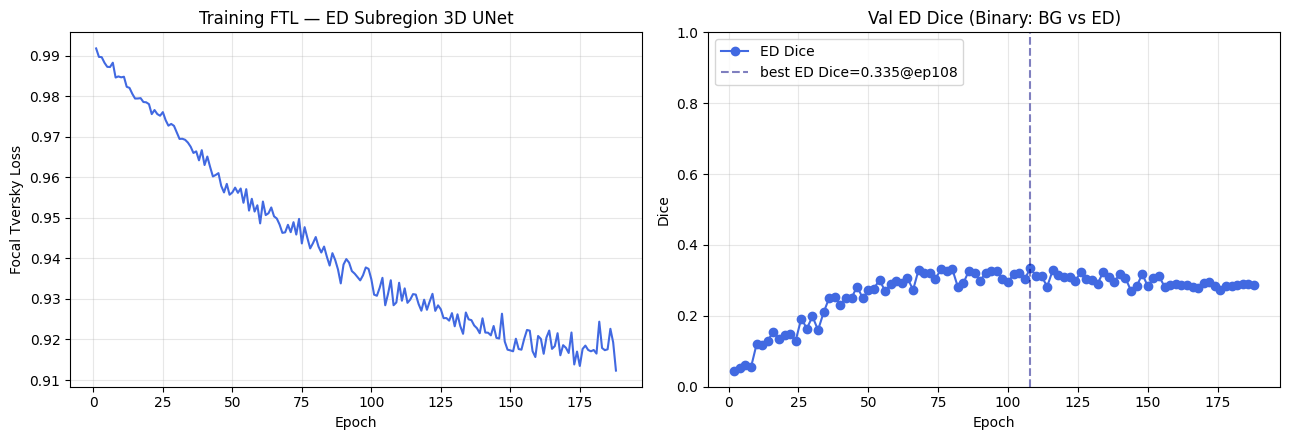

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(range(1, len(epoch_loss_values)+1), epoch_loss_values,
             lw=1.5, color="royalblue")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Focal Tversky Loss")
axes[0].set_title("Training FTL — ED Subregion 3D UNet")
axes[0].grid(alpha=0.3)

if val_metric_values:
    val_df = pd.DataFrame(val_metric_values)
    axes[1].plot(val_df["epoch"], val_df["ED_dice"], "o-",
                 lw=1.5, color="royalblue", label="ED Dice")
    axes[1].axvline(best_metric_epoch, ls="--", c="navy", alpha=0.5,
                    label=f"best ED Dice={best_metric:.3f}@ep{best_metric_epoch}")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Dice")
    axes[1].set_ylim(0, 1)
    axes[1].set_title("Val ED Dice (Binary: BG vs ED)")
    axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
out_path = RUN_DIR / "figures" / "training_curves_ed.png"
plt.savefig(out_path, dpi=140, bbox_inches="tight")
plt.show()


## Cell 11 — Test-Set Evaluation
Reloads best weights. Reports **ED Dice** and **HD95** per subject.
Saves predictions as binary NIfTI (0=BG, 1=ED).

In [27]:
dice_metric_t = DiceMetric(
    include_background=False, reduction=MetricReduction.MEAN_BATCH, get_not_nans=True,
)
hd95_metric_t = HausdorffDistanceMetric(
    include_background=False, percentile=95.0, reduction=MetricReduction.MEAN_BATCH,
)

test_ds = Dataset(data=test_files, transform=test_transforms)
test_loader = DataLoader(
    test_ds, batch_size=1, shuffle=False,
    num_workers=DL_NUM_WORKERS, pin_memory=torch.cuda.is_available(),
    persistent_workers=True, collate_fn=pad_list_data_collate,
)

raw_model = CBAMUNet3D(
    in_channels=IN_CHANNELS, out_channels=OUT_CHANNELS,
    channels=UNET_CHANNELS, strides=UNET_STRIDES, num_res_units=NUM_RES_UNITS,
).to(DEVICE)
raw_model.load_state_dict(torch.load(RUN_DIR / BEST_MODEL_NAME, map_location=DEVICE))
raw_model.eval()

test_inferer = partial(
    sliding_window_inference,
    roi_size=SW_ROI, sw_batch_size=SW_BATCH,
    predictor=raw_model, overlap=SW_OVERLAP,
)

per_subject = []
print("Running ED test-set evaluation...")
print(f"{'Idx':>4}  {'Subject':<25}  {'ED Dice':>8}  {'HD95':>8}")
print("-" * 55)

with torch.no_grad():
    for idx, tb in enumerate(test_loader, 1):
        sid = tb["subject_id"][0]
        ti  = torch.cat([tb[k].to(DEVICE) for k in IMAGE_KEYS], dim=1)
        tl  = tb["label"].to(DEVICE)

        with autocast(enabled=USE_AMP):
            to_logits = test_inferer(ti)     # (1, 2, D, H, W)

        to_list = decollate_batch(to_logits)
        tl_list = decollate_batch(tl)
        to_bin  = [post_pred(p)  for p in to_list]
        tl_bin  = [post_label(l) for l in tl_list]

        dice_metric_t.reset()
        dice_metric_t(y_pred=to_bin, y=tl_bin)
        ed_d = float(dice_metric_t.aggregate()[0].mean().item())

        try:
            hd95_metric_t.reset()
            hd95_metric_t(y_pred=to_bin, y=tl_bin)
            hd95 = float(hd95_metric_t.aggregate().mean().item())
        except Exception:
            hd95 = float("nan")

        # Save prediction as binary NIfTI (0=BG, 1=ED)
        pred_label = to_bin[0].argmax(dim=0).cpu().numpy().astype(np.uint8)
        ref_path   = [f for f in test_files if f["subject_id"] == sid][0]["label"]
        ref_img    = nib.load(ref_path)
        nib.save(
            nib.Nifti1Image(pred_label, ref_img.affine),
            str(RUN_DIR / "predictions" / f"{sid}_ED_pred.nii.gz")
        )

        per_subject.append({
            "subject_id": sid, "dice_ED": ed_d, "hd95_mm": hd95,
        })
        print(f"{idx:4d}  {sid:<25}  {ed_d:8.4f}  {hd95:8.2f}")

per_df = pd.DataFrame(per_subject).sort_values("dice_ED", ascending=False)
per_df.to_csv(RUN_DIR / "test_metrics_ed.csv", index=False)
print(f"\nMean ED Dice : {per_df['dice_ED'].mean():.4f}")
print(f"Median ED Dice: {per_df['dice_ED'].median():.4f}")
print(f"Saved: {RUN_DIR / 'test_metrics_ed.csv'}")


ValueError: persistent_workers option needs num_workers > 0

## Cell 12 — Reload Instructions

In [ ]:
print("=" * 60)
print(f" Best ED Dice (val): {best_metric:.4f} @ epoch {best_metric_epoch}")
print(f" Best model: {RUN_DIR / BEST_MODEL_NAME}")
print("=" * 60)
print("""
To reload for inference:

  from your_notebook import CBAMUNet3D
  import torch

  model = CBAMUNet3D(
      in_channels=4, out_channels=2,
      channels=(32,64,128,256,320),
      strides=(2,2,2,2), num_res_units=2,
  )
  model.load_state_dict(torch.load("best_3dunet_ed.pth"))
  model.eval()

Input:  4-channel MRI (T1n, T1c, T2w, T2f) — T2/FLAIR most important
Output: Binary mask — 0=Background, 1=ED (Peritumoral Edema)
Loss:   Focal Tversky (α=0.3, β=0.7, γ=0.75) — penalises missed ED
Attn:   CBAM (Channel + Spatial) — suppresses background noise
""")
